# Stage 4: Sentiment 整合定价方案

**创新点**：将 VAE 从 Risk Reversal Surface 学到的潜变量（sentiment）作为新特征，加入 NN(MSE) 与 NN(自定义损失) 模型，评估对定价准确性的提升。

- **Sentiment 定义**：RR surface VAE 的 2 维 latent，表征市场情绪/偏斜结构
- **防泄露**：VAE 仅用 2401-2411 训练；预测时使用**前一交易日**的 sentiment
- **对比**：与 stage_3 导出的 baseline 指标对比

| 输入 | 输出 |
|------|------|
| `full_option_trading_data.csv`、`rr_surface_vae_train_only.pt`（stage_1） | NN+Sentiment(MSE)、NN+Sentiment(自定义) 的 MAE/RMSE/MAPE |

In [2]:
import pandas as pd
import numpy as np
from OptionPricingModel import (
    OptionPricingModel,
    extract_expiry_yymm,
    compute_metrics,
    set_seed,
    SEED,
)
from FlexibleMLP import FlexibleMLP, create_combined_loss
from RiskReversalSurfaceVAE import RiskReversalSurfaceVAE
from OptionPricingReporter import OptionPricingReporter

set_seed()

In [3]:
# 加载数据，划分训练集(2401-2411)与测试集(2412)
df = pd.read_csv("full_option_trading_data.csv")
df["expiry_yymm"] = df["order_book_id"].apply(extract_expiry_yymm)
train_yymm = [f"24{i:02d}" for i in range(1, 12)]
df_train = df[df["expiry_yymm"].isin(train_yymm)].copy()
df_test = df[df["expiry_yymm"] == "2412"].copy()

def clean_option_data(d):
    d = d.dropna(subset=["underlying_close", "strike_price", "time_to_expire", "risk_free_rate", "close", "hv_20d", "call_put", "iv"])
    d = d[d["time_to_expire"] > 5/365]  # 剔除到期时间小于5天的"末日轮"
    d = d[d["close"] >= 0.2]  # 期权最低结算价 0.2
    d = d[d["hv_20d"] > 1e-6]
    d = d[d["iv"] > 1e-8]  # 排除 iv 缺失或异常小值
    return d

df_train = clean_option_data(df_train)
df_test = clean_option_data(df_test)
print(f"训练集: {len(df_train)}, 测试集: {len(df_test)}")

训练集: 42349, 测试集: 8701


In [4]:
# VAE：仅用 2401-2411 训练，避免数据泄露
import os
vae = RiskReversalSurfaceVAE(latent_dim=2, beta=0.01)
data_list_train, dates_train = vae.prepare_dataset(full_df=df_train)

vae_path = "rr_surface_vae_train_only.pt"
if os.path.exists(vae_path):
    vae.load_model(vae_path)
    print("已加载 VAE 模型（训练集专用）")
else:
    vae.fit(data_list_train, epochs=100, lr=1e-3, verbose=True)
    vae.save_model(vae_path)
    print("VAE 训练完成并保存（仅 2401-2411）")

# 需编码全部日期（含测试集）以支持「前一交易日」lookup；VAE 仅训练集拟合
data_list_all, dates_all = vae.prepare_dataset(full_df=pd.concat([df_train, df_test], ignore_index=True))
z_all = vae.encode(data_list_all)
date_to_z = {str(d)[:10]: z for d, z in zip(dates_all, z_all)}
print(f"日期 latent 数量: {len(date_to_z)}")

已加载 VAE 模型（训练集专用）
日期 latent 数量: 423


In [5]:
# 为每条期权记录匹配「前一交易日」sentiment，避免 look-ahead
all_dates_sorted = sorted(set(
    df_train["date"].astype(str).str[:10].tolist() +
    df_test["date"].astype(str).str[:10].tolist()
))

def add_sentiment_prev_day(df, date_to_z, all_dates_sorted):
    dates = df["date"].astype(str).str[:10]
    z_list = []
    for d in dates:
        if d not in all_dates_sorted:
            z_list.append(np.zeros(2, dtype=np.float32))
            continue
        idx = all_dates_sorted.index(d)
        prev_date = all_dates_sorted[idx - 1] if idx > 0 else None
        z = date_to_z.get(prev_date, np.zeros(2, dtype=np.float32)) if prev_date else np.zeros(2, dtype=np.float32)
        z_list.append(z)
    z_arr = np.array(z_list)
    return np.hstack([df[FEAT_COLS].values.astype(np.float64), z_arr])

FEAT_COLS = ["underlying_close", "strike_price", "risk_free_rate", "time_to_expire", "hv_20d", "call_put"]
X_train_sent = add_sentiment_prev_day(df_train, date_to_z, all_dates_sorted)
X_test_sent = add_sentiment_prev_day(df_test, date_to_z, all_dates_sorted)
y_train = df_train["close"].values.astype(np.float64)
y_test = df_test["close"].values.astype(np.float64)
# 无 sentiment 的 baseline 特征（供分档对比用）
X_train_base = df_train[FEAT_COLS].values.astype(np.float64)
X_test_base = df_test[FEAT_COLS].values.astype(np.float64)
print(f"特征维度（含 sentiment）: {X_train_sent.shape}")

特征维度（含 sentiment）: (42349, 8)


In [6]:
# Heston 校准（用于自定义损失）
model = OptionPricingModel()
HESTON_AVAILABLE = False
y_heston_train = None
try:
    model.calibrate_heston(df_train, price_col="close", method="least_squares", max_samples=1500)
    HESTON_AVAILABLE = True
    y_heston_train = model.price_heston_batch(df_train)
    print("Heston 校准完成")
except ImportError:
    print("QuantLib 未安装，自定义损失退化为仅价格偏差")

# 用于分档对比的 BS / Heston 预测
pred_bs_test = model.price_bs_batch(df_test)
pred_heston_test = model.price_heston_batch(df_test) if HESTON_AVAILABLE else np.full(len(df_test), np.nan)

Heston 校准完成


## Baseline NN（无 Sentiment，供分档对比）

In [7]:
# Baseline NN(MSE) 与 NN(自定义) 无 sentiment，用于四模型分档对比
nn_mse_base = FlexibleMLP(input_dim=6, hidden_dims=[64, 64, 32], activation="relu", dropout=0.1, random_state=SEED)
nn_mse_base.fit(X_train_base, y_train, epochs=80, batch_size=256, lr=1e-3, verbose=False)
pred_nn_mse_base_test = nn_mse_base.predict(X_test_base)

loss_combined = create_combined_loss(alpha=0.7, beta=0.3)
nn_custom_base = FlexibleMLP(input_dim=6, hidden_dims=[64, 64, 32], activation="relu", dropout=0.1, random_state=SEED)
if y_heston_train is not None:
    nn_custom_base.fit(X_train_base, y_train, loss_fn=loss_combined, y_heston=y_heston_train,
                       epochs=80, batch_size=256, lr=1e-3, verbose=False)
else:
    nn_custom_base.fit(X_train_base, y_train, loss_fn=loss_combined,
                       epochs=80, batch_size=256, lr=1e-3, verbose=False)
pred_nn_custom_base_test = nn_custom_base.predict(X_test_base)
print("Baseline NN(MSE):", compute_metrics(y_test, pred_nn_mse_base_test))
print("Baseline NN(自定义):", compute_metrics(y_test, pred_nn_custom_base_test))

Baseline NN(MSE): {'MAE': 18.80241590359474, 'RMSE': 31.790803540702317, 'MAPE': 38.25986212424409}
Baseline NN(自定义): {'MAE': 20.18860646440111, 'RMSE': 35.245620456462305, 'MAPE': 23.666720208464845}


## NN(MSE) + Sentiment

In [8]:
nn_mse_sent = FlexibleMLP(
    input_dim=8,
    hidden_dims=[64, 64, 32],
    activation="relu",
    dropout=0.1,
    random_state=SEED,
)
nn_mse_sent.fit(X_train_sent, y_train, epochs=80, batch_size=256, lr=1e-3, verbose=True)
pred_nn_mse_sent_test = nn_mse_sent.predict(X_test_sent)
print("NN(MSE)+Sentiment 测试集:", compute_metrics(y_test, pred_nn_mse_sent_test))

  Epoch 20/80, Loss: 1595.552473
  Epoch 40/80, Loss: 1424.504522
  Epoch 60/80, Loss: 1274.940394
  Epoch 80/80, Loss: 1195.828750
NN(MSE)+Sentiment 测试集: {'MAE': 20.583627684348453, 'RMSE': 32.59261048645085, 'MAPE': 48.21305882944707}


## NN(自定义损失) + Sentiment

In [9]:
loss_combined = create_combined_loss(alpha=0.7, beta=0.3)
nn_custom_sent = FlexibleMLP(
    input_dim=8,
    hidden_dims=[64, 64, 32],
    activation="relu",
    dropout=0.1,
    random_state=SEED,
)
if y_heston_train is not None:
    nn_custom_sent.fit(X_train_sent, y_train, loss_fn=loss_combined, y_heston=y_heston_train,
                       epochs=80, batch_size=256, lr=1e-3, verbose=True)
else:
    nn_custom_sent.fit(X_train_sent, y_train, loss_fn=loss_combined,
                       epochs=80, batch_size=256, lr=1e-3, verbose=True)
pred_nn_custom_sent_test = nn_custom_sent.predict(X_test_sent)
print("NN(自定义)+Sentiment 测试集:", compute_metrics(y_test, pred_nn_custom_sent_test))

  Epoch 20/80, Loss: 22.875355
  Epoch 40/80, Loss: 21.880035
  Epoch 60/80, Loss: 20.870344
  Epoch 80/80, Loss: 20.379255
NN(自定义)+Sentiment 测试集: {'MAE': 21.555643639472994, 'RMSE': 36.85154277379019, 'MAPE': 23.631387707285274}


## 与 Stage 3 Baseline 对比

## Call / Put 分档损失统计（正确区分虚值/实值）

- **ATM**：S/K ∈ [0.97, 1.03]（与 stage_3 一致）
- **Call**：OTM S/K<0.97，ITM S/K>1.03
- **Put**：OTM S/K>1.03，ITM S/K<0.97

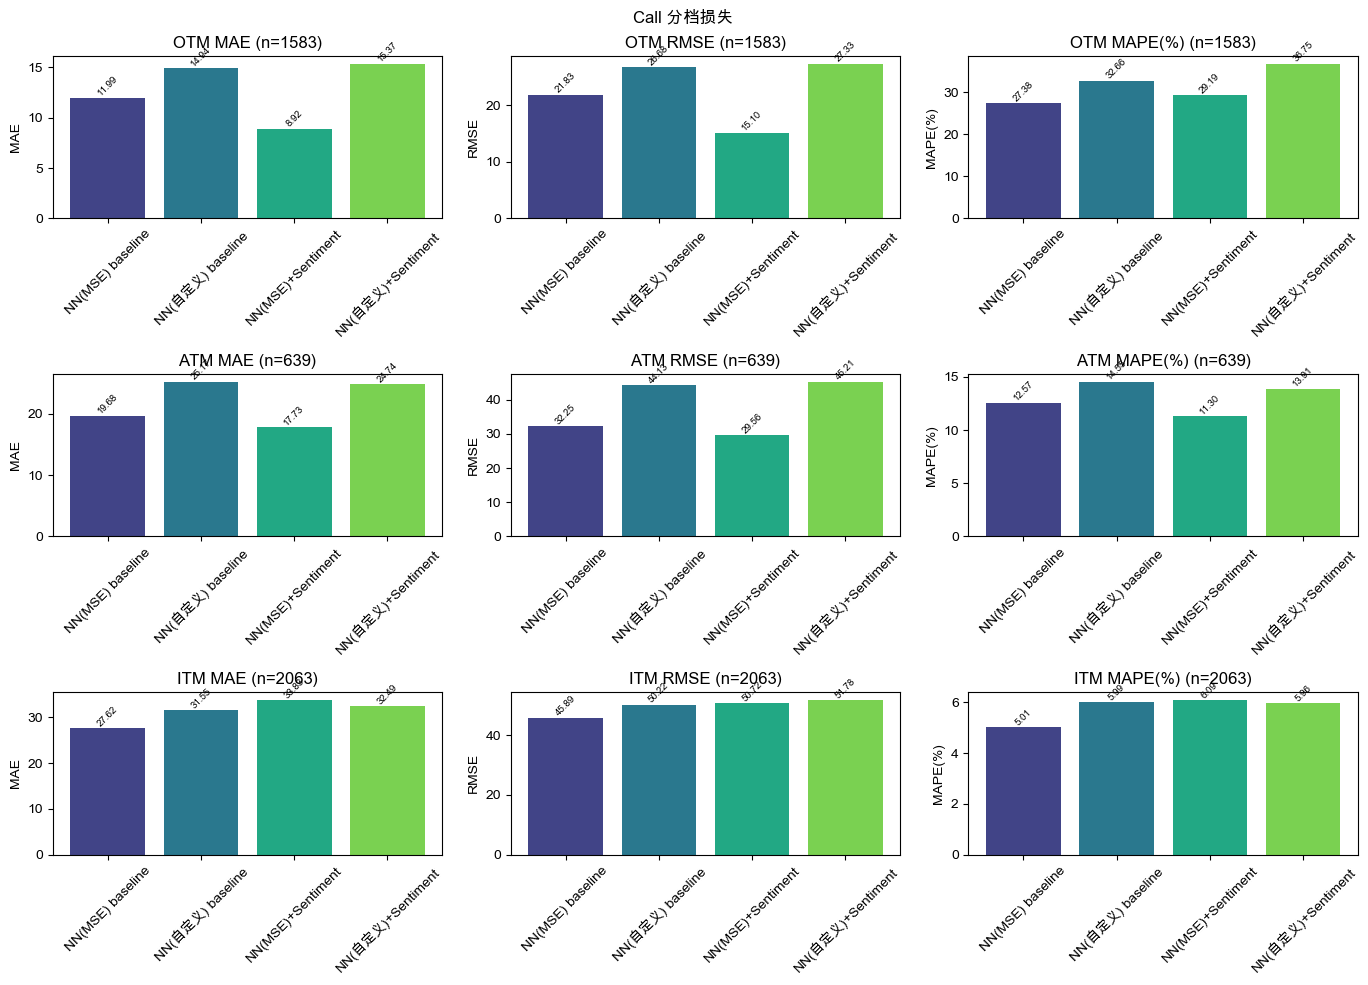

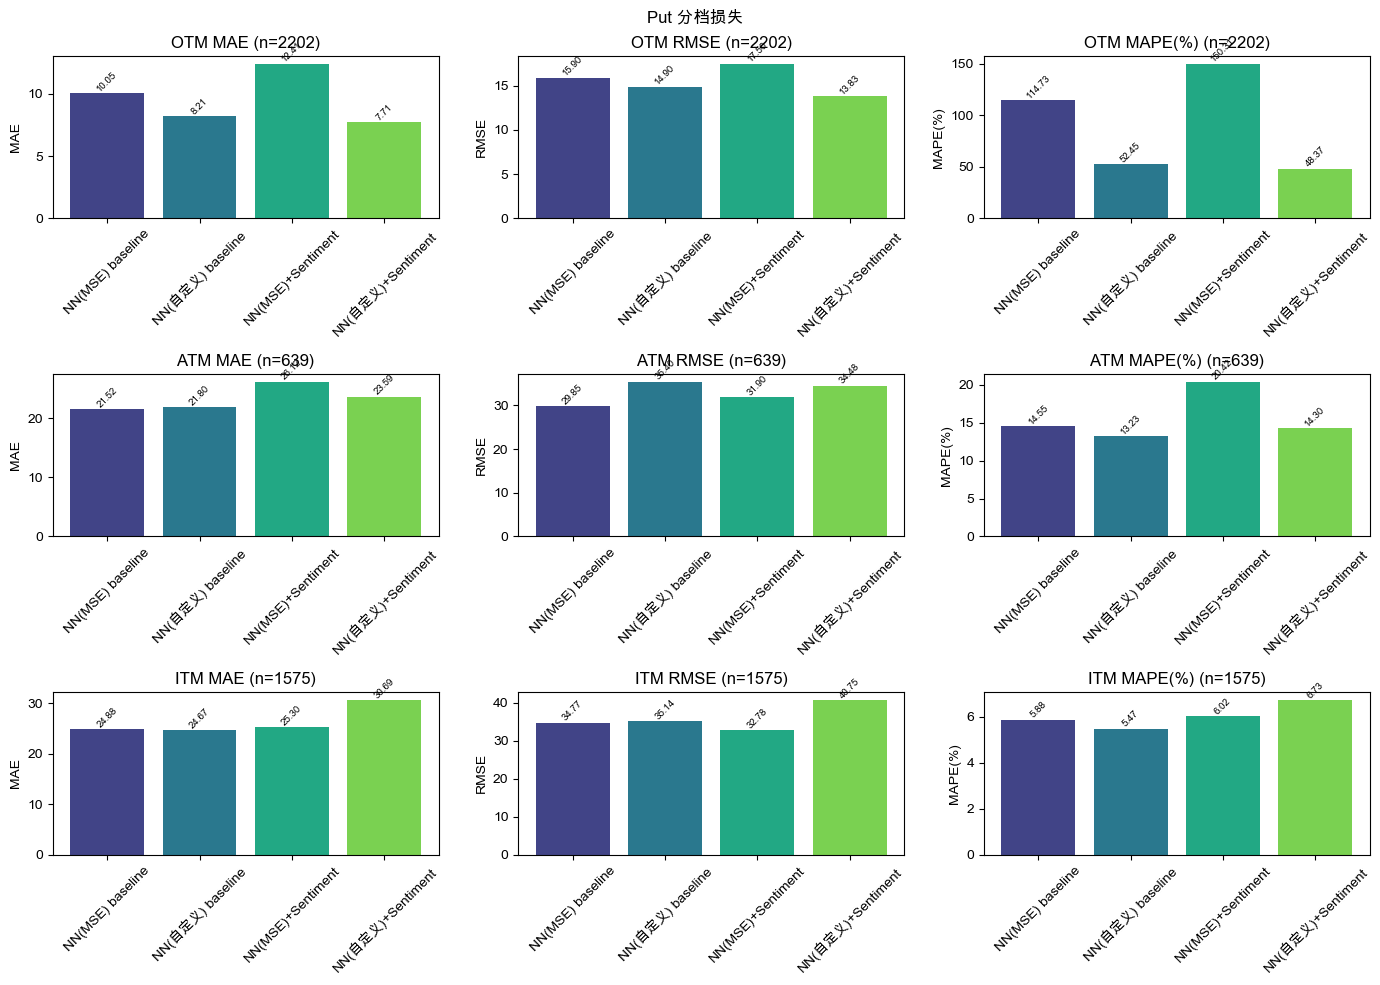

已导出 stage_4_zone_metrics.csv

--- LaTeX 格式（Stage 4 分档）---

% Call MAE
\begin{table}
\caption{Call MAE}
\begin{tabular}{lrrr}
zone & OTM & ATM & ITM \\
model &  &  &  \\
BS (hv_20d) & %.2f & %.2f & %.2f \\
Heston (校准) & %.2f & %.2f & %.2f \\
NN (MSE) & %.2f & %.2f & %.2f \\
NN (自定义损失) & %.2f & %.2f & %.2f \\
NN(MSE) baseline & %.2f & %.2f & %.2f \\
NN(MSE)+Sentiment & %.2f & %.2f & %.2f \\
NN(自定义) baseline & %.2f & %.2f & %.2f \\
NN(自定义)+Sentiment & %.2f & %.2f & %.2f \\
\end{tabular}
\end{table}


% Call RMSE
\begin{table}
\caption{Call RMSE}
\begin{tabular}{lrrr}
zone & OTM & ATM & ITM \\
model &  &  &  \\
BS (hv_20d) & %.2f & %.2f & %.2f \\
Heston (校准) & %.2f & %.2f & %.2f \\
NN (MSE) & %.2f & %.2f & %.2f \\
NN (自定义损失) & %.2f & %.2f & %.2f \\
NN(MSE) baseline & %.2f & %.2f & %.2f \\
NN(MSE)+Sentiment & %.2f & %.2f & %.2f \\
NN(自定义) baseline & %.2f & %.2f & %.2f \\
NN(自定义)+Sentiment & %.2f & %.2f & %.2f \\
\end{tabular}
\end{table}


% Call MAPE(%)
\begin{table}
\caption{Call MAPE(%)}

In [10]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = ['Arial Unicode MS']

m = df_test["moneyness(S/K)"].values
cp = df_test["call_put"].values  # 0=Call, 1=Put

# Call: OTM S/K<0.97, ATM 0.97-1.03, ITM S/K>1.03
mask_call_otm = (cp == 0) & (m < 0.97)
mask_call_atm = (cp == 0) & (m >= 0.97) & (m <= 1.03)
mask_call_itm = (cp == 0) & (m > 1.03)
# Put: ITM S/K<0.97, ATM 0.97-1.03, OTM S/K>1.03
mask_put_itm = (cp == 1) & (m < 0.97)
mask_put_atm = (cp == 1) & (m >= 0.97) & (m <= 1.03)
mask_put_otm = (cp == 1) & (m > 1.03)

model_preds = [
    ("NN(MSE) baseline", pred_nn_mse_base_test),
    ("NN(自定义) baseline", pred_nn_custom_base_test),
    ("NN(MSE)+Sentiment", pred_nn_mse_sent_test),
    ("NN(自定义)+Sentiment", pred_nn_custom_sent_test),
]

def build_zone_summary(masks, zone_names):
    rows = []
    for zone, mask in zip(zone_names, masks):
        n = mask.sum()
        if n == 0:
            continue
        y_z = y_test[mask]
        for name, pred in model_preds:
            met = compute_metrics(y_z, pred[mask])
            rows.append({"档位": zone, "模型": name, "样本数": n, **met})
    df = pd.DataFrame(rows)
    return df.rename(columns={"MAPE": "MAPE(%)"})

# Call 分档
masks_call = [mask_call_otm, mask_call_atm, mask_call_itm]
summary_call = build_zone_summary(masks_call, ["OTM", "ATM", "ITM"])
masks_put = [mask_put_otm, mask_put_atm, mask_put_itm]
summary_put = build_zone_summary(masks_put, ["OTM", "ATM", "ITM"])

# 使用 Reporter 统一可视化、加载 S3、导出、LaTeX
reporter_s4 = OptionPricingReporter()
reporter_s4.add_zone(
    pd.concat([summary_call.assign(option_type="Call"), summary_put.assign(option_type="Put")]),
    stage="S4",
)
try:
    reporter_s4.load_csv("stage_3_zone_metrics.csv")
except FileNotFoundError:
    pass
reporter_s4.plot_zone(split_call_put=True, stage="S4")
reporter_s4.save_csv("stage_4_zone_metrics.csv", which="zone", stage="S4")
print("已导出 stage_4_zone_metrics.csv")
print("\n--- LaTeX 格式（Stage 4 分档）---\n")
print(reporter_s4.to_latex_zone())
print("\n--- LaTeX 格式（S3 vs S4 对比）---\n")
print(reporter_s4.to_latex_comparison(model_mapping={"NN (MSE)": "NN(MSE) baseline", "NN (自定义损失)": "NN(自定义) baseline"}))

In [11]:
# 汇总：Stage 4 + Sentiment 结果
rows_s4 = [
    {"model": "NN (MSE)+Sentiment", **compute_metrics(y_test, pred_nn_mse_sent_test)},
    {"model": "NN (自定义损失)+Sentiment", **compute_metrics(y_test, pred_nn_custom_sent_test)},
]
summary_s4 = pd.DataFrame(rows_s4)
if "MAPE" in summary_s4.columns and "MAPE(%)" not in summary_s4.columns:
    summary_s4 = summary_s4.rename(columns={"MAPE": "MAPE(%)"})

# 先导出 Stage 4 结果（统一 schema：含 stage 和 exported_at）
# 清空之前的 overall 数据，避免重复添加
reporter_s4._df_overall = None
reporter_s4.add_overall(summary_s4, stage="S4")
reporter_s4.save_csv("stage_4_test_metrics.csv", which="overall")
print("已导出 stage_4_test_metrics.csv")

# 从 CSV 文件读取 Stage 3 和 Stage 4 结果进行对比（格式统一，都有 exported_at）
try:
    s3 = pd.read_csv("stage_3_test_metrics.csv")
    s4 = pd.read_csv("stage_4_test_metrics.csv")
    
    # 筛选 NN 模型并重命名
    s3_nn = s3[s3["model"].isin(["NN (MSE)", "NN (自定义损失)"])].copy()
    s3_nn["模型"] = s3_nn["model"].replace({
        "NN (MSE)": "NN(MSE) baseline", 
        "NN (自定义损失)": "NN(自定义) baseline"
    })
    
    s4_nn = s4.copy()
    s4_nn["模型"] = s4_nn["model"].replace({
        "NN (MSE)+Sentiment": "NN(MSE)+Sentiment",
        "NN (自定义损失)+Sentiment": "NN(自定义)+Sentiment"
    })
    
    # 统一列顺序：模型、指标、时间戳
    cols_display = ["模型", "MAE", "RMSE", "MAPE(%)", "exported_at"]
    s3_nn = s3_nn[cols_display]
    s4_nn = s4_nn[cols_display]
    
    summary_compare = pd.concat([s3_nn, s4_nn], ignore_index=True)
    print("\nStage 3 vs Stage 4 对比（Sentiment 对定价准确性的影响）:")
    display(summary_compare)
except FileNotFoundError as e:
    print(f"未找到 CSV 文件: {e}")
    print("请先运行 stage_3 并导出结果")

已导出 stage_4_test_metrics.csv

Stage 3 vs Stage 4 对比（Sentiment 对定价准确性的影响）:


,模型,MAE,RMSE,MAPE(%),exported_at
0,NN(MSE) baseline,16.707121,29.265946,27.653801,2026-02-17 17:45:03
1,NN(自定义) baseline,20.188606,35.245620,23.666720,2026-02-17 17:45:03
2,NN(MSE)+Sentiment,20.583628,32.592610,48.213059,2026-02-17 18:08:50
3,NN(自定义)+Sentiment,21.555644,36.851543,23.631388,2026-02-17 18:08:50
